# Landmark threshold — fitting the S2 citation predicate

The evidence behind the fitted constants of the rule that splits a seed's citers
into **Landmarks** and **Latest Publications**:

$$\text{is\_landmark}(citer) = citer.cited\_by \ge \max\left(\text{FLOOR},\; a\,(age+1)^{p}\cdot\left(\tfrac{seed.cited\_by}{median}\right)^{\beta}\right)$$

The design (why a predicate, the two normalizations, the 20–40 target) is
`docs/citation-threshold.md`; this notebook only shows the numbers the fit landed
on. It reads the committed `corpus_s2.csv.gz` and `model_s2.metadata.json` and
reuses the trainer's own functions, so what's plotted is exactly what the app
will serve.

Three questions:
1. Does a 2-parameter age curve `T(age) = a(age+1)^p` fit the data?
2. Does a single-parameter `S(seed)` hold every seed in the 20–40 band?
3. How do the worked examples land?

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np

from ml_pipelines.landmark_threshold import collect_s2, train_s2

if not collect_s2.CORPUS_PATH.exists():
    raise SystemExit(
        f"{collect_s2.CORPUS_PATH.name} not found — run, on the corpus machine:\n"
        "  uv run python -m ml_pipelines.landmark_threshold.collect_s2"
    )
if not train_s2.METADATA_PATH.exists():
    raise SystemExit(
        "model_s2.metadata.json not found — fit first:\n"
        "  uv run python -m ml_pipelines.landmark_threshold.train_s2"
    )

metadata = json.loads(train_s2.METADATA_PATH.read_text())
as_of_year = metadata["as_of_year"]
scale, exponent, beta, floor = metadata["a"], metadata["p"], metadata["beta"], metadata["floor"]
seeds = train_s2.load_seeds(as_of_year=as_of_year)
inputs = train_s2.build_inputs(seeds)
print(f"{len(seeds)} seeds; median seed cited_by = {inputs.median_seed:.0f}")
print(f"fitted: a={scale}  p={exponent}  beta={beta}  floor={floor}")

1502 seeds; median seed cited_by = 2002
fitted: a=38.1218  p=0.8026  beta=0.6608  floor=9.6351


## 1. The age curve

For a **median** seed (scale term = 1) the bar is just `max(FLOOR, T(age))`. Plot
the empirical citer citation-count quantiles at each age against the fitted curve:
does the monotone 2-parameter form track the data, or does the curve bend in a way
a table would catch and `a(age+1)^p` misses?

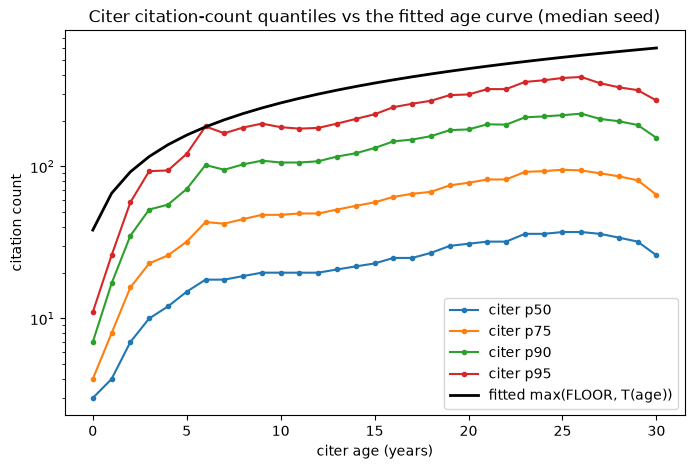

In [2]:
ages = inputs.ages
cited = inputs.cited_by
counts = inputs.counts

age_values = np.arange(0, train_s2.AGE_MAX + 1)
quantile_levels = [50, 75, 90, 95]
empirical = {level: [] for level in quantile_levels}
for age in age_values:
    mask = ages == age
    if not mask.any():
        for level in quantile_levels:
            empirical[level].append(np.nan)
        continue
    # Expand the (value, count) bins to a weighted sample for the percentile.
    sample = np.repeat(cited[mask], counts[mask].astype(int))
    for level in quantile_levels:
        empirical[level].append(np.percentile(sample, level))

fitted_curve = scale * (age_values + 1.0) ** exponent

figure, axes = plt.subplots(figsize=(8, 5))
for level in quantile_levels:
    axes.plot(age_values, empirical[level], marker=".", label=f"citer p{level}")
axes.plot(age_values, np.maximum(floor, fitted_curve), color="black", linewidth=2,
          label="fitted max(FLOOR, T(age))")
axes.set_yscale("log")
axes.set_xlabel("citer age (years)")
axes.set_ylabel("citation count")
axes.set_title("Citer citation-count quantiles vs the fitted age curve (median seed)")
axes.legend()
plt.show()

## 2. The achieved spread — does one `S()` hold the band?

The design's stated fitting risk: a single-parameter `S(seed)` must keep *every*
seed's landmark count inside a 2× band across three orders of magnitude of seed
size. Recompute each seed's landmark count under the fitted rule and look at the
distribution and the spread by seed-size decade.

in band (20–40): 31.6%    reachable seeds: 100.0%
count percentiles: {'5': 7.0, '25': 20.0, '50': 35.0, '75': 59.8, '95': 135.0}


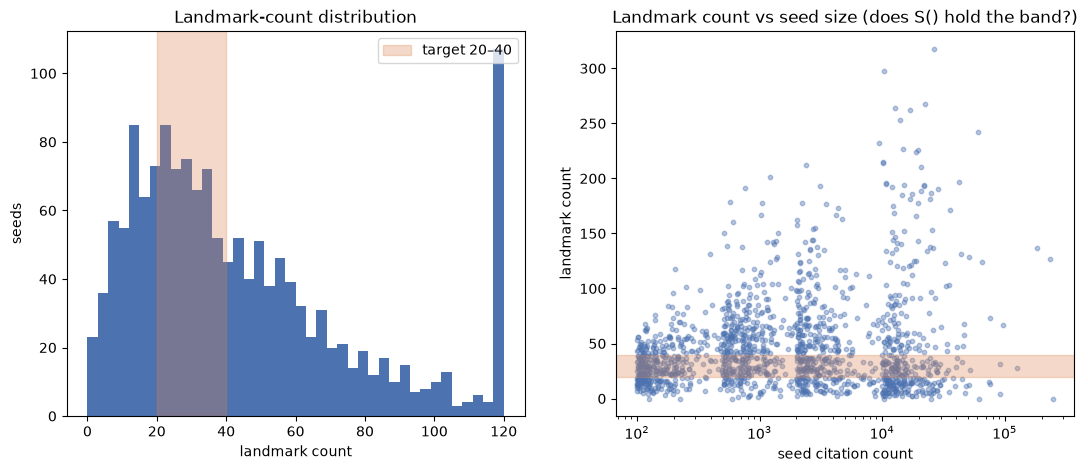

In [3]:
landmark_count = train_s2.landmark_counts(inputs, scale, exponent, beta, floor)
reachable = inputs.max_possible >= train_s2.TARGET_LOW
in_band = (landmark_count >= train_s2.TARGET_LOW) & (landmark_count <= train_s2.TARGET_HIGH)
print(f"in band (20–40): {in_band.mean():.1%}    reachable seeds: {reachable.mean():.1%}")
print("count percentiles:", metadata["achieved_spread"]["count_percentiles"])

figure, (left, right) = plt.subplots(1, 2, figsize=(13, 5))
left.hist(np.clip(landmark_count, 0, 120), bins=40, color="#4c72b0")
left.axvspan(train_s2.TARGET_LOW, train_s2.TARGET_HIGH, color="#dd8452", alpha=0.3,
             label="target 20–40")
left.set_xlabel("landmark count")
left.set_ylabel("seeds")
left.set_title("Landmark-count distribution")
left.legend()

seed_cited = inputs.seed_ratio * inputs.median_seed
right.scatter(seed_cited, landmark_count, s=10, alpha=0.4, color="#4c72b0")
right.axhspan(train_s2.TARGET_LOW, train_s2.TARGET_HIGH, color="#dd8452", alpha=0.3)
right.set_xscale("log")
right.set_xlabel("seed citation count")
right.set_ylabel("landmark count")
right.set_title("Landmark count vs seed size (does S() hold the band?)")
plt.show()

## 3. The worked examples

Hawking / DQN / QMIX / *Attention* carried through, so an absurd count is caught
by eye. The semantic claim: a few dozen field-definers, not hundreds.

In [4]:
worked = metadata["achieved_spread"]["worked_examples"]
print(f"{'seed':<28}{'year':>6}{'cited_by':>10}{'landmarks':>11}{'max':>7}")
for label, stats in worked.items():
    print(f"{label:<28}{stats['seed_year']:>6}{stats['seed_cited_by']:>10}"
          f"{stats['landmarks']:>11}{stats['max_possible']:>7}")

seed                          year  cited_by  landmarks    max
Hawking Radiation             1974      5143         26   3714
DQN                           2013     13792         94   9715
QMIX                          2018      2046         56   1440
Attention Is All You Need     2017    183110        137 119672


## Verdict

**The age curve form holds; the 20–40 band does not — and no pool-independent
rule would.**

For fixed `p` and `FLOOR`, a seed's landmark count depends on the rule only
through the multiplier `m = a·(seed/median)^beta` (a citer is admitted iff
`m <= cited_by/(age+1)^p`). So each seed has an *exact* interval of multipliers
that lands it in band, and the question becomes whether a line through
`(log seed_size, log m)` can stab 1,502 intervals. Searching that whole family:

- **ceiling ~35%** in band for *any* `(a, p, beta, FLOOR)`; the fit reached 31.6%
- **99.5–100%** of seeds are individually reachable at *some* multiplier
- required-multiplier residual scatter **1.9× (1σ)** vs a **1.65×**-wide target

The needle is narrower than the wobble. Ruled out: a more flexible `S()` (decade
medians 35/42/30 are already centered — the miss is within-decade scatter), a
second pool-independent predictor (seed age: R² 0.782 → 0.786, coverage
unchanged), and any `p`/`FLOOR` (29–35% across the sweep).

**The overall R² = 0.79 is misleading**: it is nearly all *between* size cohorts.
Within a cohort it collapses — 0.17 (1k–10k cites), 0.19 (≥10k), 0.10 (≥30k).
Seed size buys a coarse "bigger seed, higher bar" and little else; where the bar
belongs depends on the citer distribution's *shape*, which no seed-level feature
sees.

**Big seeds are the hardest** (residual scatter 2.10× for ≥10k, 2.19× for ≥30k,
vs 1.75× below 1k) — and they are what users actually explore. At a 10–80 band
Hawking (32) and QMIX (54) sit in band while DQN (88) and *Attention* (114)
overflow.

A predicate reads one citer and never the pool; a landmark **count** is a pool
property. The rule can center the distribution, not pin it. Widening the band is
the lever that works (10–80 → 73.7%); an exact count guarantee belongs in the
display layer, where the sliders already cap what is drawn.